# Exploring the XFOIL python library
In order to validate the results from the neural network we can compare its output to XFOIL, witch is established 2D airfoil analysis software.

In [12]:
import os
print("Notebook runs in:", os.getcwd())
print("xfoil.exe exists:", os.path.exists("../xfoil.exe"))

Notebook runs in: f:\AI_projekt\Code\airfoil-ai\notebooks
xfoil.exe exists: True


# Velocity to Re conversion

$Re = \frac{V c}{ν}$

$\nu \approx 1.5 \times 10^{-5}\ \text{m}^2/\text{s}$

note: c=1 because thats what the AirfRANS uses and will provade most similar results. 

In [ ]:
visc = 1.5e-5
vel = 50.0
c = 1

Re = (vel * c) / (visc)
print("Reynolds number:", Re)


Reynolds number: 3333333.333333333


In [ ]:
def vel_to_Re(Vel, c=1, visc=1.5e-5):
    return (Vel * c) / (visc)

# Running xfoil as a subprocess

In [ ]:
import subprocess

xfoil_path = "../xfoil.exe"

commands = """NACA 2412
OPER
VISC 3000000
ITER 200
PACC
polar.txt

ASEQ -5 15 0.5
PACC

QUIT
"""

result = subprocess.run(
    [xfoil_path],
    input=commands,         
    capture_output=True,
    text=True,
    cwd="..",                 
    timeout=60                
)

print("--- What XFOIL printed ---")
print(result.stdout[-2000:])   

### lets chceck the output polar.txt

In [19]:
with open("../polar.txt") as f:
    print(f.read())

  
       XFOIL         Version 6.99
  
 Calculated polar for: NACA 2412                                       
  
 1 1 Reynolds number fixed          Mach number fixed         
  
 xtrf =   1.000 (top)        1.000 (bottom)  
 Mach =   0.000     Re =     3.000 e 6     Ncrit =   9.000
  
   alpha    CL        CD       CDp       CM     Top_Xtr  Bot_Xtr
  ------ -------- --------- --------- -------- -------- --------
  -5.000  -0.3202   0.00677   0.00189  -0.0527   0.8310   0.0507
  -4.500  -0.2640   0.00657   0.00167  -0.0526   0.8060   0.0606
  -4.000  -0.2081   0.00638   0.00146  -0.0525   0.7776   0.0761
  -3.500  -0.1518   0.00622   0.00129  -0.0525   0.7479   0.0935
  -3.000  -0.0956   0.00607   0.00114  -0.0525   0.7168   0.1185
  -2.500  -0.0393   0.00593   0.00102  -0.0525   0.6847   0.1487
  -2.000   0.0170   0.00582   0.00093  -0.0525   0.6523   0.1842
  -1.500   0.0734   0.00572   0.00086  -0.0526   0.6201   0.2267
  -1.000   0.1297   0.00563   0.00082  -0.0526   0.5878   0.2

Data seems to be working lets work with it further


In [24]:
import numpy as np

data = np.loadtxt("../polar.txt", skiprows=12)

alpha = data[:, 0]   # first column is angle of attack
cl    = data[:, 1]   # second column is lift coefficient
cd    = data[:, 2]   # third column is drag coefficient
cm    = data[:, 4]   # fifth column is moment coefficient

print("alpha:", alpha)
print("cl:", cl)

alpha: [-5.  -4.5 -4.  -3.5 -3.  -2.5 -2.  -1.5 -1.  -0.5  0.   0.5  1.   1.5
  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5  7.   7.5  8.   8.5
  9.   9.5 10.  10.5 11.  11.5 12.  12.5 13.  13.5 14.  14.5 15. ]
cl: [-0.3202 -0.264  -0.2081 -0.1518 -0.0956 -0.0393  0.017   0.0734  0.1297
  0.1861  0.2423  0.298   0.354   0.4098  0.4655  0.5203  0.5736  0.6245
  0.6779  0.7383  0.8065  0.8645  0.9111  0.9591  1.0088  1.0589  1.1094
  1.1597  1.2095  1.2585  1.3071  1.3546  1.4004  1.4455  1.4881  1.5282
  1.5643  1.5951  1.6217  1.6511  1.6775]


now we have the correct variables therefor we can plot the numbers using matplotlib

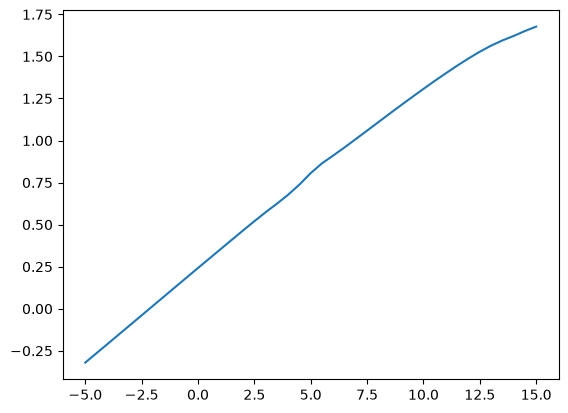

In [26]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("../polar.txt", skiprows=12)

alpha = data[:, 0]   # first column is angle of attack
cl    = data[:, 1]   # second column is lift coefficient
cd    = data[:, 2]   # third column is drag coefficient
cm    = data[:, 4]   # fifth column is moment coefficient

plt.plot(alpha, cl, label="Lift Coefficient (Cl)")

# Making an xfoil function that takes Velocity, NACA / .dat points and range of angles and returns Alpha Cl Cd Cm

In [ ]:
import subprocess
import numpy as np
import os

def load_dat(path):
    coords = np.loadtxt(path, skiprows=1)
    x = coords[:, 0]
    y = coords[:, 1]
    return x, y

def run_xfoil(airfoil, velocity, alpha_start=-5, alpha_end=15, alpha_step=0.5,
              chord=1.0, visc=1.5e-5, xfoil_path="../xfoil.exe", n_iter=200):
    
    polar = "../polar.txt"
    re = (velocity * chord) / (visc)
    
    if os.path.exists(polar):
        os.remove(polar)

    if isinstance(airfoil, str):
        airfoil_cmd = f"NACA {airfoil}"
    else:
        x, y = airfoil                            # ← coordinates come from the argument
        dat_name = "temp_airfoil.dat"             # how XFOIL sees it
        dat_path = os.path.join("..", dat_name)   # how the notebook sees it
        coords = np.column_stack([x, y])
        np.savetxt(dat_path, coords, header="airfoil", comments="")
        airfoil_cmd = f"LOAD {dat_name}"          # ← short name for XFOIL
    
    polar_file = "polar.txt"

    commands = f"""{airfoil_cmd}
OPER
VISC {re}
ITER {n_iter}
PACC
{polar_file}

ASEQ {alpha_start} {alpha_end} {alpha_step}
PACC

QUIT
"""
    
    result = subprocess.run(
        [xfoil_path],
        input=commands,         
        capture_output=True,
        text=True,
        cwd="..",                 
        timeout=60                
    )
    
    data = np.loadtxt("../polar.txt", skiprows=12)
    alpha = data[:, 0]
    cl    = data[:, 1]
    cd    = data[:, 2]
    cm    = data[:, 4]
    
    return alpha, cl, cd, cm


# --- test both branches ---

alpha, cl, cd, cm = run_xfoil("2412", velocity=50)
print(f"NACA:         points {len(alpha)}, Cl max = {cl.max():.3f}")

x, y = load_dat("../NACA2412.dat")
alpha2, cl2, cd2, cm2 = run_xfoil((x, y), velocity=50)
print(f"cordinates file : points {len(alpha2)}, Cl max = {cl2.max():.3f}")

NACA:         points 39, Cl max = 1.688
cordinates .dat : points 39, Cl max = 1.695
